In [29]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install lightgbm
!pip install matplotlib

In [1]:
global_random_seed = 42

# Step 1: Loading and preprocessing 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from re import sub
label_encoder = LabelEncoder()

df = pd.read_csv('Data2026/measures.csv', sep=";", decimal=",")
df = df.rename(columns = lambda x:sub('[^A-Za-z0-9_]+', '', x)) # Remove special characters
X = df.drop('activity', axis=1).drop('subject', axis=1)
X_grouping_feature = df['subject']
y = label_encoder.fit_transform(df['activity'])
print("Training data loaded")

df = None # Just to prevent us from accidentally reading from this stale variable

df = pd.read_csv('Data2026/to_predict.csv', sep=";", decimal=",")
df = df.rename(columns = lambda x:sub('[^A-Za-z0-9_]+', '', x)) # Remove special characters
X_to_predict = df.drop('subject', axis=1)
X_to_predict_grouping_feature = df['subject']
print("Testing data loaded")

df = None # Just to prevent us from accidentally reading from this stale variable

Training data loaded
Testing data loaded


### Previous analysis has shown that several features are extremely correlated. Therefore, we will remove the highly correlated features to ensure their quality. We do this before the train-test split, of course, to not have to do this twice.

In [3]:
def remove_correlated_features(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"Removing {len(to_drop)} features due to correlation")
    return X.drop(columns=to_drop), to_drop

X, dropped = remove_correlated_features(X)
X_to_predict = X_to_predict.drop(columns=dropped)

Removing 308 features due to correlation


# Now we will split the complete training set into two subsets (for later error estimation): The "train" set and the "test" set. We use StratifiedGroupKFold to avoid groups being split between the sets while preserving the class distribution.

In [4]:
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=global_random_seed) # Technically this creates 10 different splits, but we will just take the first split.
# Since there are 10 splits, the test set is 10% of the data, and the train set is 90% of the data
train_idx, test_idx = next(sgkf.split(X, y, X_grouping_feature))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

### Compare the class distributions in the training and test sets by using class histograms

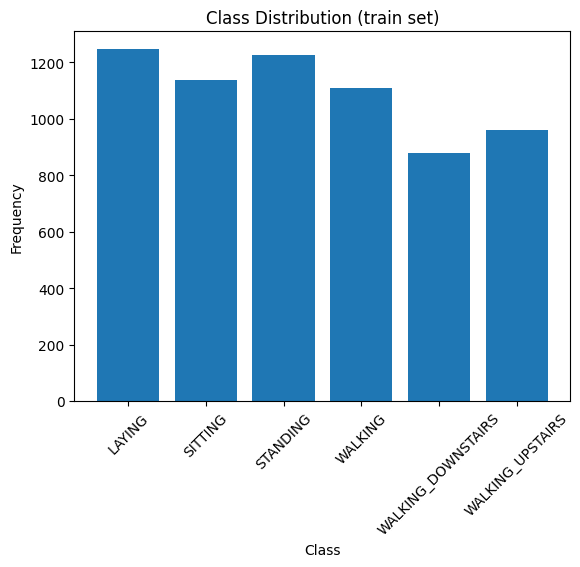

In [5]:
import matplotlib.pyplot as plt

train_classes_encoded, train_counts = np.unique(y_train, return_counts=True)
train_classes = label_encoder.inverse_transform(train_classes_encoded)
plt.bar(train_classes, train_counts)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Class Distribution (train set)")
plt.xticks(rotation=45)
plt.show()

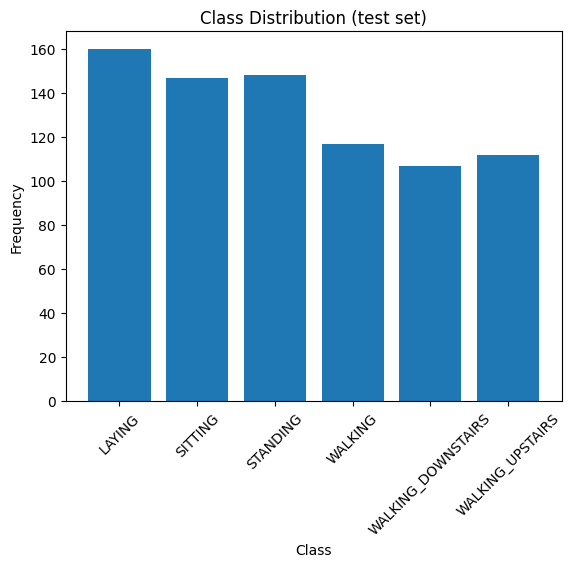

In [6]:
test_classes_encoded, test_counts = np.unique(y_test, return_counts=True)
test_classes = label_encoder.inverse_transform(test_classes_encoded)
plt.bar(test_classes, test_counts)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Class Distribution (test set)")
plt.xticks(rotation=45)
plt.show()

# Onto the actual model. We use Logistic Regression. Right now, we will calculate the F1-Score, to evaluate whether we are choosing the right approach - we will train the final model in the next step

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score

gkf = GroupKFold(n_splits=5)

cv_scores = []

model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, X_train_grouping_feature)):
    print(f"Fold {fold+1}")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train[train_idx]
    y_val = y_train[val_idx]

    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    score = f1_score(y_val, preds, average="macro")

    print("F1-macro:", score)
    cv_scores.append(score)

print("\nMean F1-macro:", np.mean(cv_scores))

Fold 1
F1-macro: 0.8857867108378036
Fold 2
F1-macro: 0.8978724479742627
Fold 3
F1-macro: 0.9757955345575419
Fold 4
F1-macro: 0.9634290060760081
Fold 5
F1-macro: 0.9402895159499932

Mean F1-macro: 0.9326346430791219


# The F1 Scores look very good. Now we train the model on the complete data and apply it onto the test data

In [9]:
model.fit(X_train, y_train)
y_predicted = model.predict(X_to_predict)
y_predicted = label_encoder.inverse_transform(y_predicted)

In [10]:
y_predicted

array(['STANDING', 'STANDING', 'LAYING', ..., 'WALKING', 'WALKING',
       'STANDING'], shape=(2947,), dtype=object)

# The final step is to save this predicted data in a csv file

In [11]:
csvFileContent = "activity"
for v in y_predicted:
    csvFileContent += "\n" + str(v)

In [12]:
with open("my_prediction.csv", "w") as f:
    f.write(csvFileContent)